In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st
import statsmodels.api as sm
import pylab as py

from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("C:/Users/afarm/.cache/kagglehub/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset/versions/1/online_gaming_behavior_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [3]:
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


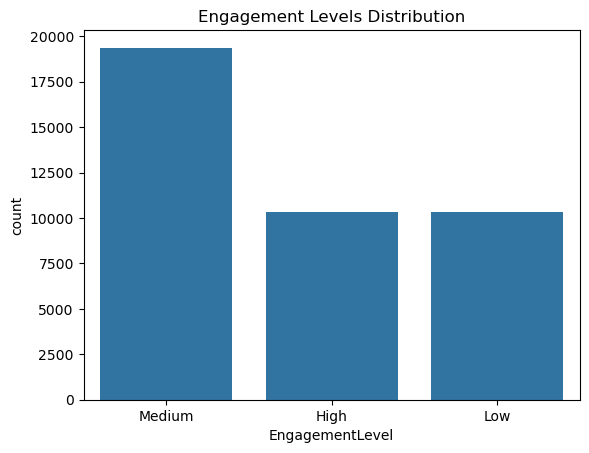

In [4]:
sns.countplot(x="EngagementLevel", data=df)
plt.title("Engagement Levels Distribution")
plt.show()

In [5]:
df = df.drop(columns=["PlayerID"])
y = df["EngagementLevel"]
X = df.drop(columns=["EngagementLevel"])

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)



In [6]:
df.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Logistic Regression Model

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
# Accuracy of the Model
print(accuracy_score(y_test, y_pred_log))

0.8239040839265642


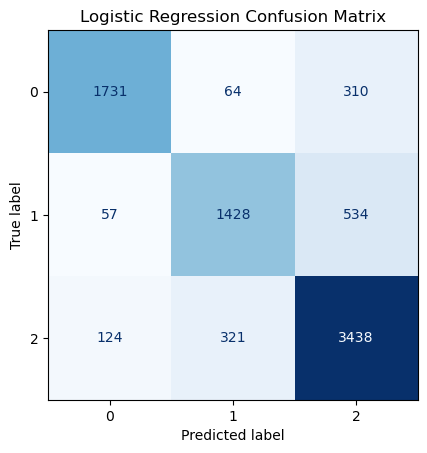

In [9]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
# Notice lots of mediums were predicted as high -- blurry line between medium and high in the model?

In [10]:
importance = log_model.coef_[0]

# Match with feature names
feature_names = X.columns

lr_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(lr_importance)

                      Feature  Importance
3             SessionsPerWeek    2.161921
4   AvgSessionDurationMinutes    1.862484
5                 PlayerLevel    0.171789
6        AchievementsUnlocked    0.170745
1               PlayTimeHours    0.020792
12       GameGenre_Simulation    0.018946
2             InGamePurchases    0.017457
14         GameGenre_Strategy    0.009931
16      GameDifficulty_Medium    0.006832
15        GameDifficulty_Hard    0.004330
11              GameGenre_RPG    0.003804
13           GameGenre_Sports    0.001722
7                 Gender_Male   -0.006128
8             Location_Europe   -0.007282
9              Location_Other   -0.015713
0                         Age   -0.021349
10               Location_USA   -0.024059


<Axes: xlabel='Importance', ylabel='Feature'>

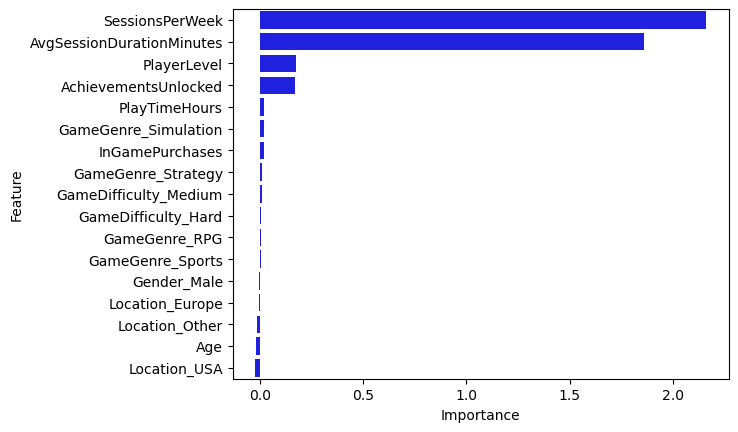

In [11]:
sns.barplot(data=lr_importance,y="Feature",x="Importance",color="blue")

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("Accuracy with 5 neighbors:", accuracy_score(y_test, y_pred_knn))

c:\Users\afarm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\afarm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\afarm\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\afarm\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Accuracy with 5 neighbors: 0.6827775696265768


In [13]:
knn2 = KNeighborsClassifier(n_neighbors=50)
knn2.fit(X_train_scaled, y_train)

y_pred_knn2 = knn2.predict(X_test_scaled)
print("Accuracy with 50 neighbors:", accuracy_score(y_test, y_pred_knn2))

Accuracy with 50 neighbors: 0.7194954414886974


In [14]:
knn3 = KNeighborsClassifier(n_neighbors=75)
knn3.fit(X_train_scaled, y_train)

y_pred_knn3 = knn3.predict(X_test_scaled)
print("Accuracy with 75 neighbors:", accuracy_score(y_test, y_pred_knn3))

Accuracy with 75 neighbors: 0.7033845385287874


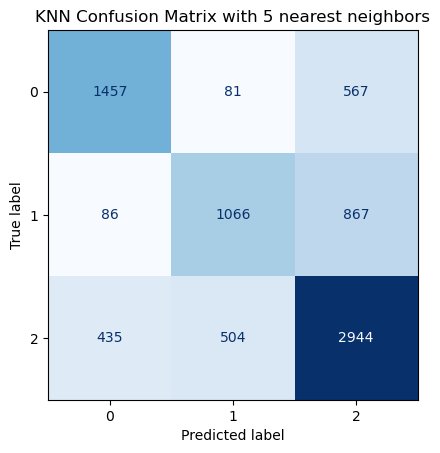

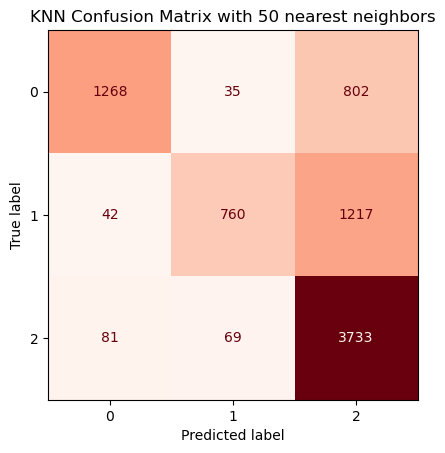

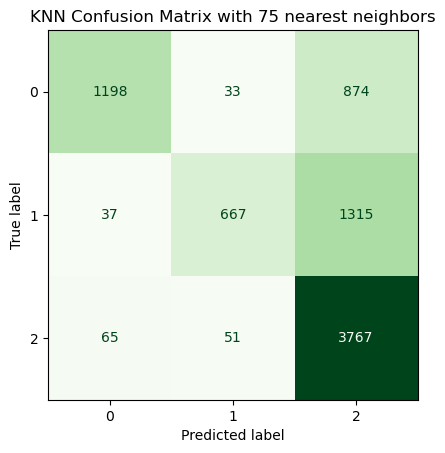

In [15]:
cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("KNN Confusion Matrix with 5 nearest neighbors")
plt.show()

cm2 = confusion_matrix(y_test, y_pred_knn2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot(cmap="Reds", colorbar=False, values_format="d")
plt.title("KNN Confusion Matrix with 50 nearest neighbors")
plt.show()

cm3 = confusion_matrix(y_test, y_pred_knn3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot(cmap="Greens", colorbar=False, values_format="d")
plt.title("KNN Confusion Matrix with 75 nearest neighbors")
plt.show()

